
Loading dataset...
Genes after cleanup: 24611
Samples: 40

Sample counts:
late period     24
early period    12
control          4
Name: count, dtype: int64

Signature genes: 11
Genes found in dataset: 11
Overlap: {'BATF', 'RPGRIP1', 'C3AR1', 'C9ORF95', 'ZDHHC19', 'KIAA1370', 'MTCH1', 'HLA-DPB1', 'GNA15', 'TGFBI', 'CEACAM1'}

Signature genes after filtering: 11

Running GSVA...

Running ssGSEA...

Computing COMPASS score...

Samples used for ROC: 16

AUC comparison
---------------------
GSVA: 0.75
ssGSEA: 0.9583333333333333
COMPASS: 0.9791666666666666


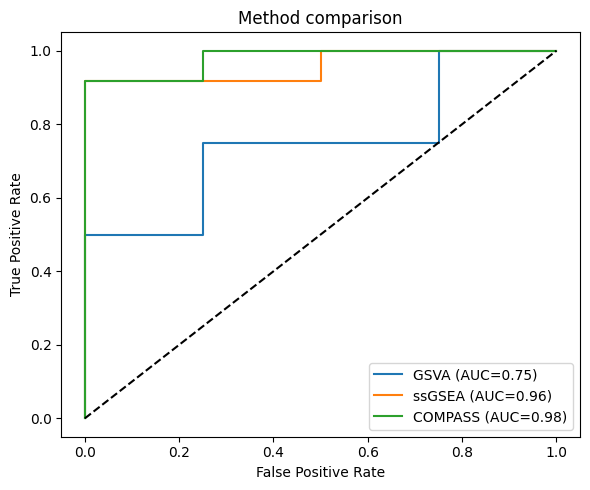

In [42]:
import pandas as pd
import numpy as np
import gseapy as gp
import StepMiner
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import compass_score
# ===============================
# PDF
# ===============================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
def getPDF(cfile):
    from matplotlib.backends.backend_pdf import PdfPages

    pdf = PdfPages(cfile)
    return pdf

def closePDF(pdf):
    import datetime
    d = pdf.infodict()
    d['Title'] = 'Plots'
    d['Author'] = 'Saptarshi'
    d['Subject'] = "heatmap"
    d['Keywords'] = 'heatmap'
    d['CreationDate'] = datetime.datetime(2021, 1, 18)
    d['ModDate'] = datetime.datetime.today()
    pdf.close()
    
cfile = "Final_plot/test.pdf"
pdf = getPDF(cfile)

# ===============================
# USER INPUT
# ===============================

DATASET = "GSE21802.txt"

GROUP_CASE = "early period"
GROUP_CONTROL = "control"

#SIGNATURE = ["CEACAM1","ZDHHC19","C9ORF95","GNA15","BATF","C3AR1"]

#SIGNATURE = ["KIAA1370","TGFBI","MTCH1","RPGRIP1","HLA-DPB1"]

SIGNATURE = ["CEACAM1","ZDHHC19","C9ORF95","GNA15","BATF","C3AR1","KIAA1370","TGFBI","MTCH1","RPGRIP1","HLA-DPB1"]

# weights must follow the SAME order as SIGNATURE
#WEIGHTS = [1,1,1,1,1,1]
#WEIGHTS = [1,1,1,1,1]
WEIGHTS = [1,1,1,1,1,1,-1,-1,-1,-1,-1]
# ===============================
# Load expression
# ===============================

print("\nLoading dataset...")

expr = pd.read_csv(DATASET, sep="\t")

expr = expr.rename(columns={expr.columns[0]:"Gene"})
expr = expr.set_index("Gene")

expr = expr.drop(columns=["Description"], errors="ignore")

# clean gene symbols
expr.index = expr.index.astype(str).str.upper().str.strip()

# remove invalid rows
expr = expr[expr.index != "---"]
expr = expr[expr.index.notna()]
expr = expr[expr.index.str.len() > 1]

# average duplicate genes
expr = expr.groupby(expr.index).mean()

print("Genes after cleanup:",expr.shape[0])
print("Samples:",expr.shape[1])

# ===============================
# Sample groups
# ===============================

groups = pd.Series(expr.columns, index=expr.columns)
groups = groups.str.replace(r"\.\d+$","",regex=True)

print("\nSample counts:")
print(groups.value_counts())

# ===============================
# Prepare signature
# ===============================

SIGNATURE = [g.upper().strip() for g in SIGNATURE]

overlap = set(SIGNATURE).intersection(expr.index)

print("\nSignature genes:",len(SIGNATURE))
print("Genes found in dataset:",len(overlap))
print("Overlap:",overlap)

# keep only genes present in dataset
sig_filtered = [g for g in SIGNATURE if g in expr.index]

print("\nSignature genes after filtering:",len(sig_filtered))

# adjust weights to filtered genes
weights_filtered = np.array([
WEIGHTS[i] for i,g in enumerate(SIGNATURE) if g in sig_filtered
])

gene_sets = {"SIGNATURE":sig_filtered}

# ===============================
# GSVA
# ===============================

print("\nRunning GSVA...")

gsva_res = gp.gsva(
data=expr,
gene_sets=gene_sets,
method="gsva",
kcdf="Gaussian",
min_size=1,
max_size=5000
)

gsva_scores = gsva_res.res2d.copy()

gsva_scores = gsva_scores.rename(columns={
"Name":"Sample",
"ES":"GSVA"
})

gsva_scores = gsva_scores.set_index("Sample")

gsva_scores["GSVA"] = pd.to_numeric(gsva_scores["GSVA"], errors="coerce")

# ===============================
# ssGSEA
# ===============================

print("\nRunning ssGSEA...")

ssgsea_res = gp.ssgsea(
data=expr,
gene_sets=gene_sets,
min_size=1,
max_size=5000
)

ssgsea_scores = ssgsea_res.res2d.copy()

ssgsea_scores = ssgsea_scores.rename(columns={
"Name":"Sample",
"ES":"ssGSEA"
})

ssgsea_scores = ssgsea_scores.set_index("Sample")

ssgsea_scores["ssGSEA"] = pd.to_numeric(ssgsea_scores["ssGSEA"], errors="coerce")

# ===============================
# COMPASS score
# ===============================

def stepminer_threshold(v):

    arr = np.array(v)
    arr.sort()

    s = StepMiner.fitstep(arr)

    return float(s["threshold"])


compass_scores = compass_score(expr, sig_filtered, weights_filtered)

compass_scores = compass_scores.to_frame("COMPASS")

# ===============================
# Merge scores
# ===============================

scores = pd.concat([
gsva_scores["GSVA"],
ssgsea_scores["ssGSEA"],
compass_scores
],axis=1)

scores["Group"] = groups

scores = scores[scores["Group"].isin([GROUP_CASE,GROUP_CONTROL])]

scores = scores.dropna()

print("\nSamples used for ROC:",scores.shape[0])

# ===============================
# ROC AUC
# ===============================

labels = (scores["Group"] == GROUP_CASE).astype(int)

auc_gsva = roc_auc_score(labels, scores["GSVA"])
auc_ssgsea = roc_auc_score(labels, scores["ssGSEA"])
auc_compass = roc_auc_score(labels, scores["COMPASS"])

print("\nAUC comparison")
print("---------------------")
print("GSVA:",auc_gsva)
print("ssGSEA:",auc_ssgsea)
print("COMPASS:",auc_compass)

# ===============================
# Plot AUC comparison
# ===============================

auc_df = pd.DataFrame({
"Method":["GSVA","ssGSEA","COMPASS"],
"AUC":[auc_gsva,auc_ssgsea,auc_compass]
})

# ===============================
# Plot AUC comparison
# ===============================

#fig, ax = plt.subplots(figsize=(5,4))

#sns.barplot(data=auc_df, x="Method", y="AUC", ax=ax)

#ax.set_ylim(0,1)
#ax.set_title("Method Comparison (ROC AUC)")

#plt.tight_layout()

# Save figure to PDF
#pdf.savefig(fig, transparent=True, bbox_inches='tight')

#plt.show()


######

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6,5))

for method in ["GSVA","ssGSEA","COMPASS"]:

    fpr, tpr, _ = roc_curve(labels, scores[method])

    auc = roc_auc_score(labels, scores[method])

    ax.plot(fpr, tpr, label=f"{method} (AUC={auc:.2f})")

ax.plot([0,1],[0,1],'k--')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Method comparison")
ax.legend()

plt.tight_layout()

# Save figure to PDF
pdf.savefig(fig, transparent=True, bbox_inches='tight')

plt.show()
# ===============================
# Save results
# ===============================

closePDF(pdf)

scores.to_csv("Final_plot/test.txt", sep="\t")

#print("\nSaved results -> signature_method_scores.txt")

Cases: 12, Controls: 4

Fixed thresholds derived from full dataset
---------------------------------------------------------------
GSVA: threshold = 0.21447, flipped = False, full AUC = 0.750, full Sensitivity = 0.500, full Specificity = 1.000
ssGSEA: threshold = 8606.48921, flipped = False, full AUC = 0.958, full Sensitivity = 0.917, full Specificity = 1.000
COMPASS: threshold = -0.45550, flipped = False, full AUC = 0.979, full Sensitivity = 0.917, full Specificity = 1.000

Bootstrap performance summary
--------------------------------------------------------------------------
 Method  Fixed_Threshold        AUC (95% CI) Sensitivity (mean ± SD) Specificity (mean ± SD)
   GSVA         0.214465 0.742 (0.458-0.958)           0.497 ± 0.141           1.000 ± 0.000
 ssGSEA      8606.489215 0.956 (0.833-1.000)           0.914 ± 0.081           1.000 ± 0.000
COMPASS        -0.455500 0.979 (0.875-1.000)           0.916 ± 0.082           1.000 ± 0.000


/var/folders/90/cv2cm0cn4d59mdmlc468hjz00000gp/T/ipykernel_11524/3887552289.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/90/cv2cm0cn4d59mdmlc468hjz00000gp/T/ipykernel_11524/3887552289.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/Users/sasinha/miniconda3/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 11.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/sasinha/miniconda3/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 63.2% of the points cannot be placed; you may want to decrease the size of the markers or use stri

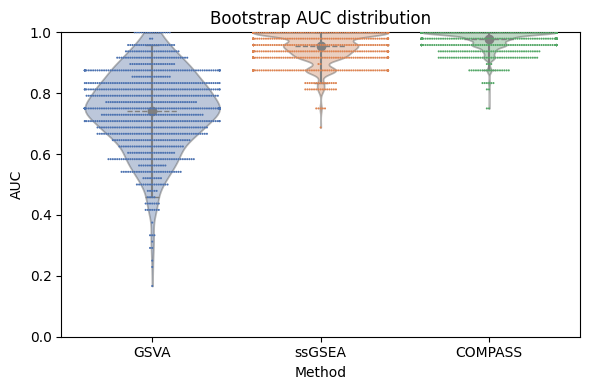

In [45]:
# ===============================
# Bootstrap AUC / Sensitivity / Specificity stability
# Stratified bootstrap + FIXED threshold from full data
# ===============================

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

N_BOOT = 1000
np.random.seed(123)   # for reproducibility

methods = ["GSVA", "ssGSEA", "COMPASS"]

boot_results = {
    "GSVA": {"AUC": [], "Sensitivity": [], "Specificity": []},
    "ssGSEA": {"AUC": [], "Sensitivity": [], "Specificity": []},
    "COMPASS": {"AUC": [], "Sensitivity": [], "Specificity": []}
}

# ===============================
# Precompute stratified indices
# ===============================
idx_case = np.where(scores["Group"] == GROUP_CASE)[0]
idx_control = np.where(scores["Group"] == GROUP_CONTROL)[0]

n_case = len(idx_case)
n_control = len(idx_control)

print(f"Cases: {n_case}, Controls: {n_control}")

# ===============================
# Full-data labels
# ===============================
labels_full = (scores["Group"] == GROUP_CASE).astype(int).values

# ===============================
# Determine fixed threshold for each method
# using full dataset and maximum Youden index
# ===============================
fixed_info = {}

for method in methods:
    vals = scores[method].values.astype(float)

    auc_full = roc_auc_score(labels_full, vals)

    flipped = False
    if auc_full < 0.5:
        vals = -vals
        auc_full = roc_auc_score(labels_full, vals)
        flipped = True

    fpr, tpr, thresholds = roc_curve(labels_full, vals)
    youden = tpr - fpr
    best_idx = np.argmax(youden)

    fixed_threshold = thresholds[best_idx]
    full_sens = tpr[best_idx]
    full_spec = 1 - fpr[best_idx]

    fixed_info[method] = {
        "flipped": flipped,
        "threshold": fixed_threshold,
        "full_auc": auc_full,
        "full_sensitivity": full_sens,
        "full_specificity": full_spec
    }

print("\nFixed thresholds derived from full dataset")
print("---------------------------------------------------------------")
for method in methods:
    print(
        f"{method}: threshold = {fixed_info[method]['threshold']:.5f}, "
        f"flipped = {fixed_info[method]['flipped']}, "
        f"full AUC = {fixed_info[method]['full_auc']:.3f}, "
        f"full Sensitivity = {fixed_info[method]['full_sensitivity']:.3f}, "
        f"full Specificity = {fixed_info[method]['full_specificity']:.3f}"
    )

# ===============================
# Stratified bootstrap
# ===============================
for i in range(N_BOOT):

    # sample cases and controls separately
    boot_case = np.random.choice(idx_case, size=n_case, replace=True)
    boot_control = np.random.choice(idx_control, size=n_control, replace=True)

    # combine and shuffle
    boot_idx = np.concatenate([boot_case, boot_control])
    np.random.shuffle(boot_idx)

    sample = scores.iloc[boot_idx].copy()
    labels_boot = (sample["Group"] == GROUP_CASE).astype(int).values

    for method in methods:
        vals = sample[method].values.astype(float)

        try:
            # apply same direction as full dataset
            if fixed_info[method]["flipped"]:
                vals = -vals

            # -----------------------------
            # AUC in bootstrap sample
            # -----------------------------
            auc = roc_auc_score(labels_boot, vals)

            # -----------------------------
            # Fixed-threshold classification
            # -----------------------------
            thr = fixed_info[method]["threshold"]
            pred = (vals >= thr).astype(int)

            tn, fp, fn, tp = confusion_matrix(labels_boot, pred, labels=[0, 1]).ravel()

            sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

            boot_results[method]["AUC"].append(auc)
            boot_results[method]["Sensitivity"].append(sens)
            boot_results[method]["Specificity"].append(spec)

        except Exception:
            continue

# ===============================
# Convert to arrays
# ===============================
for method in boot_results:
    for metric in boot_results[method]:
        boot_results[method][metric] = np.array(boot_results[method][metric], dtype=float)

# ===============================
# 95% CI function
# ===============================
def ci95(x):
    x = x[~np.isnan(x)]
    lower = np.percentile(x, 2.5)
    upper = np.percentile(x, 97.5)
    return lower, upper

# ===============================
# Summary table
# ===============================
summary_rows = []

for method in methods:
    auc_vals = boot_results[method]["AUC"]
    sens_vals = boot_results[method]["Sensitivity"]
    spec_vals = boot_results[method]["Specificity"]

    auc_mean = np.nanmean(auc_vals)
    auc_ci = ci95(auc_vals)

    sens_mean = np.nanmean(sens_vals)
    sens_sd = np.nanstd(sens_vals, ddof=1)

    spec_mean = np.nanmean(spec_vals)
    spec_sd = np.nanstd(spec_vals, ddof=1)

    summary_rows.append({
        "Method": method,
        "Direction_Flipped": fixed_info[method]["flipped"],
        "Fixed_Threshold": fixed_info[method]["threshold"],
        "Mean_AUC": auc_mean,
        "AUC_95CI_Lower": auc_ci[0],
        "AUC_95CI_Upper": auc_ci[1],
        "Sensitivity_Mean": sens_mean,
        "Sensitivity_SD": sens_sd,
        "Specificity_Mean": spec_mean,
        "Specificity_SD": spec_sd,
        "AUC (95% CI)": f"{auc_mean:.3f} ({auc_ci[0]:.3f}-{auc_ci[1]:.3f})",
        "Sensitivity (mean ± SD)": f"{sens_mean:.3f} ± {sens_sd:.3f}",
        "Specificity (mean ± SD)": f"{spec_mean:.3f} ± {spec_sd:.3f}"
    })

summary_df = pd.DataFrame(summary_rows)

print("\nBootstrap performance summary")
print("--------------------------------------------------------------------------")
print(summary_df[[
    "Method",
    "Fixed_Threshold",
    "AUC (95% CI)",
    "Sensitivity (mean ± SD)",
    "Specificity (mean ± SD)"
]].to_string(index=False))

# ===============================
# Save summary table
# ===============================
summary_df.to_csv(
    "Final_plot/test.txt",
    sep="\t",
    index=False
)

# ===============================
# Prepare dataframe for AUC violin plot
# ===============================
boot_df = pd.DataFrame({
    "AUC": np.concatenate([
        boot_results["GSVA"]["AUC"],
        boot_results["ssGSEA"]["AUC"],
        boot_results["COMPASS"]["AUC"]
    ]),
    "Method":
        ["GSVA"] * len(boot_results["GSVA"]["AUC"]) +
        ["ssGSEA"] * len(boot_results["ssGSEA"]["AUC"]) +
        ["COMPASS"] * len(boot_results["COMPASS"]["AUC"])
})

# ===============================
# Plot bootstrap AUC distribution
# ===============================
fig, ax = plt.subplots(figsize=(6,4))

palette = {
    "GSVA": "#4C72B0",
    "ssGSEA": "#DD8452",
    "COMPASS": "#55A868"
}

sns.violinplot(
    data=boot_df,
    x="Method",
    y="AUC",
    palette=palette,
    inner=None,
    cut=0,
    ax=ax
)

for pc in ax.collections:
    pc.set_alpha(0.4)

sns.swarmplot(
    data=boot_df,
    x="Method",
    y="AUC",
    palette=palette,
    size=1.5,
    ax=ax
)

means = [np.nanmean(boot_results[m]["AUC"]) for m in methods]
ci_lowers = [ci95(boot_results[m]["AUC"])[0] for m in methods]
ci_uppers = [ci95(boot_results[m]["AUC"])[1] for m in methods]

yerr = [
    np.array(means) - np.array(ci_lowers),
    np.array(ci_uppers) - np.array(means)
]

ax.errorbar(
    x=np.arange(len(methods)),
    y=means,
    yerr=yerr,
    fmt='o',
    color='gray',
    capsize=5,
    label="Mean ± 95% CI"
)

for i, mean in enumerate(means):
    ax.hlines(
        y=mean,
        xmin=i-0.15,
        xmax=i+0.15,
        colors='gray',
        linewidth=1,
        linestyles='dashed',
        zorder=11
    )

ax.set_title("Bootstrap AUC distribution")
ax.set_ylim(0.0, 1.0)

plt.tight_layout()

pdf.savefig(fig, transparent=True, bbox_inches='tight')
plt.show()

# ===============================
# Save outputs
# ===============================
scores.to_csv("Final_plot/test.txt", sep="\t", index=False)
closePDF(pdf)
plt.close(fig)